Install UMAP

In [1]:
pip install umap-learn

Load the dataset

In [2]:
from sklearn.datasets import fetch_openml

# load the data
mnist_data = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist_data.data
y = mnist_data.target

print(X)
print(y)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
['5' '0' '4' ... '4' '5' '6']


In [3]:
type(X)

numpy.ndarray

In [4]:
# load the data
mnist_data = fetch_openml('mnist_784', version=1, as_frame=True)

X = mnist_data.data
y = mnist_data.target

type(X)

pandas.core.frame.DataFrame

In [5]:
# load the data
mnist_data = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist_data.data
y = mnist_data.target

print(X)
print(y)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
['5' '0' '4' ... '4' '5' '6']


In [6]:
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


Implement UMAP

In [7]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    random_state = 42
)

X_umap = reducer.fit_transform(X)
print(X_umap.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(70000, 2)


Observation: 784 features -> 2 features

Visualize the results

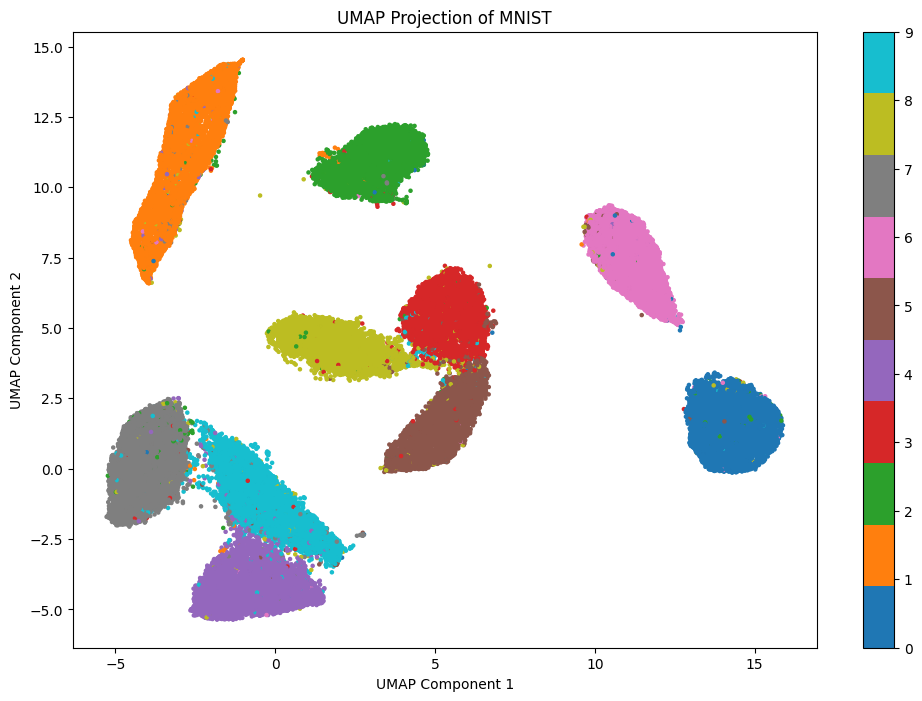

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

scatter = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=y.astype(int),
    cmap='tab10',
    s=5
)

plt.colorbar(scatter)
plt.title("UMAP Projection of MNIST")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")

plt.show()

In [9]:
import umap

reducer = umap.UMAP(
    n_neighbors=50,
    random_state = 42
)

X_umap = reducer.fit_transform(X)
print(X_umap.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(70000, 2)


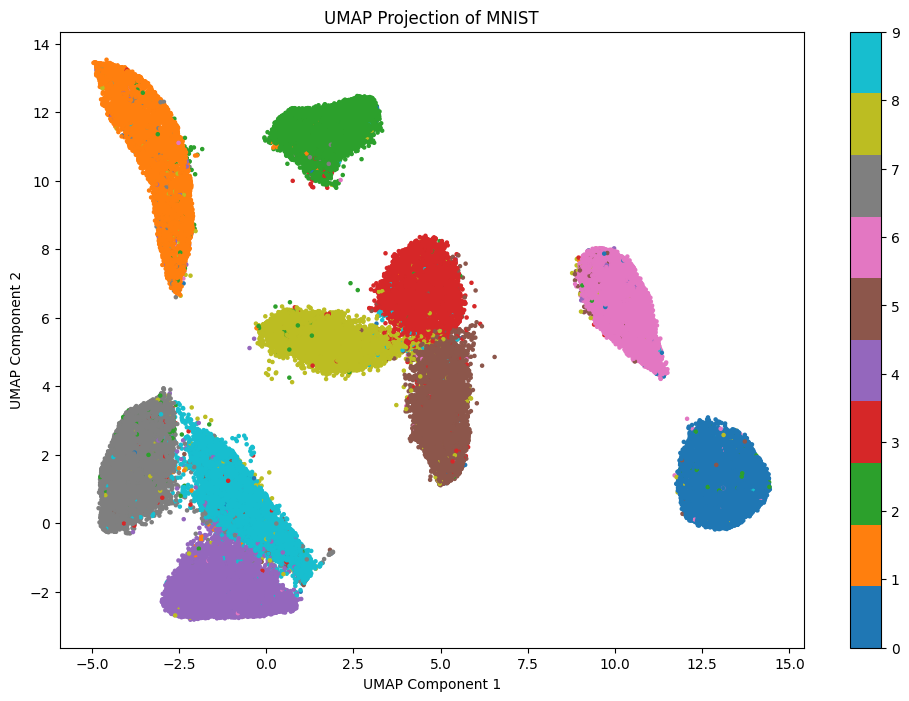

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

scatter = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=y.astype(int),
    cmap='tab10',
    s=5
)

plt.colorbar(scatter)
plt.title("UMAP Projection of MNIST")
plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")

plt.show()

PCA + UMAP Pipeline

In [11]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [12]:
wine = load_wine()
X = wine.data
y = wine.target

In [13]:
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [15]:
print(X.shape)

(178, 13)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [17]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

Train Model

In [18]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

Prediction

In [19]:
y_pred = knn.predict(X_test)
print(y_pred)

[2 0 2 0 1 0 2 0 1 0 2 2 0 1 0 1 1 1 0 1 0 1 2 1 1 1 1 2 1 0 0 1 2 0 0 0]


Model Evaluation

In [20]:
accuracy_score(y_test, y_pred)

0.7222222222222222

In [21]:
confusion_matrix(y_test, y_pred)

array([[12,  0,  2],
       [ 0, 11,  3],
       [ 2,  3,  3]])